In [1]:
import os
os.chdir("/public/home/off_liukunpeng/project/11_cluster_problem")
import scanpy as sc
import pandas as pd

In [2]:
import torch

In [3]:
torch.cuda.is_available()

True

In [4]:
from sklearn import metrics
def supervise_index(adata,predict,real_key):
    
    ARI = metrics.adjusted_rand_score(adata.obs[real_key],adata.obs[predict])
    NMI = metrics.normalized_mutual_info_score(adata.obs[real_key],adata.obs[predict])
    FMS = metrics.fowlkes_mallows_score(adata.obs[real_key],adata.obs[predict])
    AMI = metrics.adjusted_mutual_info_score(adata.obs[real_key],adata.obs[predict])
    HMG = metrics.homogeneity_score(adata.obs[real_key],adata.obs[predict])
    VMS = metrics.v_measure_score(adata.obs[real_key],adata.obs[predict])
    MIS = metrics.mutual_info_score(adata.obs[real_key],adata.obs[predict])
    return {"ARI":ARI,
            "NMI":NMI,
            "FMS":FMS,
            "AMI":AMI,
            "HMG":HMG,
            "VMS":VMS,
            'MIS':MIS}

In [5]:
!nvidia-smi

Tue Dec 30 18:37:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:35:00.0 Off |                    0 |
|  0%   31C    P0             72W /  300W |    1071MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
software_name=["DeepST","SpaGCN","STAGATE","STMGraph","AgaeSMO"]

path=[
"comparison/deepst/osf_slide2.h5ad",
"comparison/spaGCN/osf_slide2.h5ad",
"comparison/STAGATE/osf_slide2h5ad",
"comparison/STMGraph/osf_slide2.h5ad",
"test_2/osfstorage/Slide_2.h5ad",
]


In [7]:
annotation=pd.read_csv("../7_public_data/Data/osfstorage-archive/slide1_annotation.csv")
annotation

,Unnamed: 0,annotation
0,AAACAAGTATCTCCCA-1,C
1,AAACAGAGCGACTCCT-1,B
2,AAACATTTCCCGGATT-1,B
3,AAACCCGAACGAAATC-1,OT
4,AAACCGGAAATGTTAA-1,B
...,...,...
2374,TTGTGTTTCCCGAAAG-1,OT
2375,TTGTTAGCAAATTCGA-1,other
2376,TTGTTCAGTGTGCTAC-1,OT
2377,TTGTTGTGTGTCAAGA-1,other 1


In [8]:
DeepST___adata=sc.read_h5ad("comparison/deepst/osf_slide1.h5ad")
SpaGCN___adata=sc.read_h5ad("comparison/spaGCN/osf_slide1.h5ad")
STAGATE__adata=sc.read_h5ad("down_stream_analysis/orchid/stagate_slide1.h5ad")
STMGraph_adata=sc.read_h5ad("down_stream_analysis/orchid/STMGraph_slide1.h5ad")
AgaeSMO__adata=sc.read_h5ad("test_2/orchid/Slide_1_.h5ad")
DeepST___adata.obs["GrounTruth"]=list(annotation["annotation"])
SpaGCN___adata.obs["GrounTruth"]=list(annotation["annotation"])
STAGATE__adata.obs["GrounTruth"]=list(annotation["annotation"])
STMGraph_adata.obs["GrounTruth"]=list(annotation["annotation"])
AgaeSMO__adata.obs["GrounTruth"]=list(annotation["annotation"])

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default

[<Axes: title={'center': 'AgaeSMO'}, xlabel='spatial1', ylabel='spatial2'>]

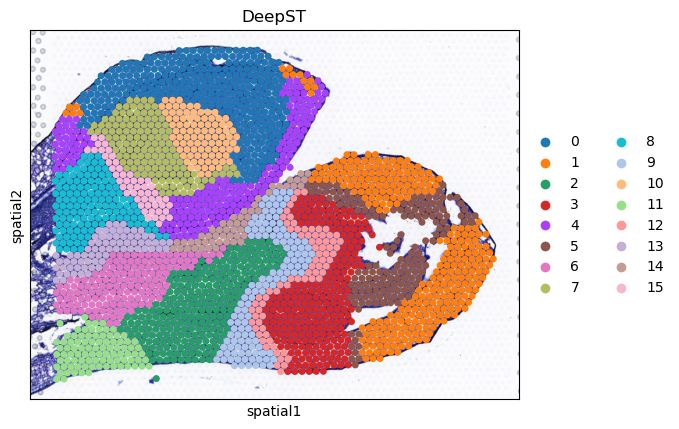

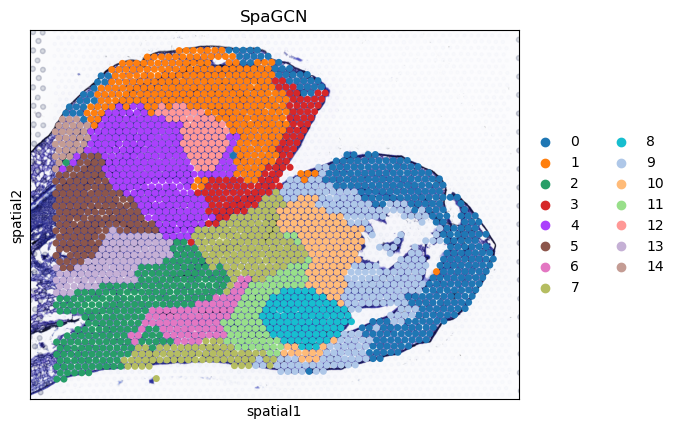

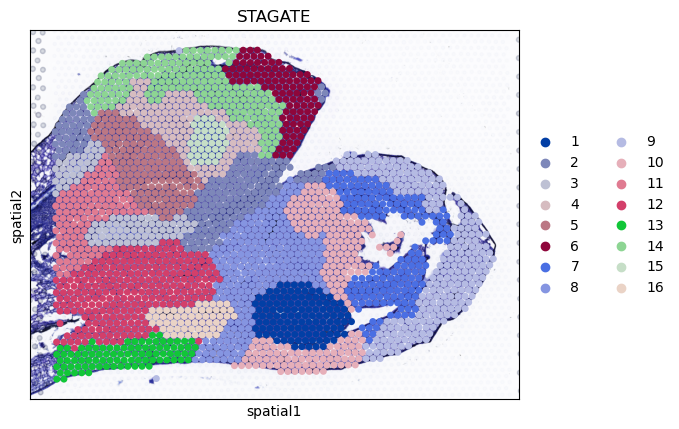

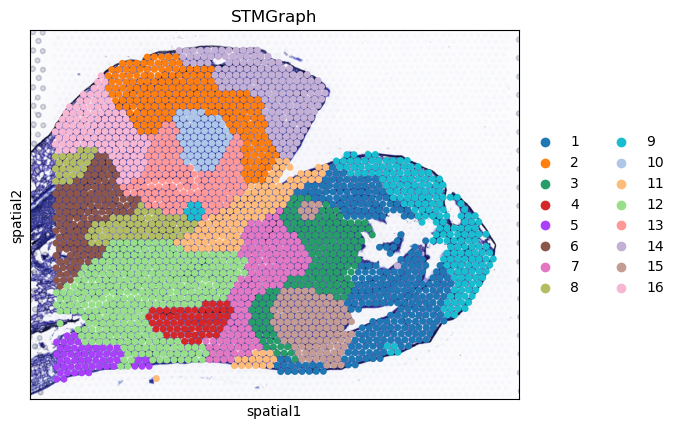

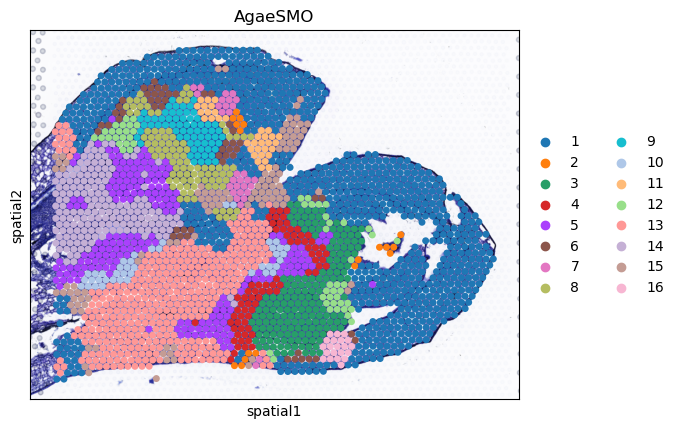

In [10]:
s_1=12
sc.pl.spatial(DeepST___adata, basis='spatial', color='DeepST_refine_domain', title='DeepST',  s=s_1, show=False)
sc.pl.spatial(SpaGCN___adata, basis='spatial', color='refined_pred',         title="SpaGCN",  s=s_1, show=False)
sc.pl.spatial(STAGATE__adata, basis='spatial', color='mclust',               title="STAGATE", s=s_1, show=False)
sc.pl.spatial(STMGraph_adata, basis='spatial', color='refine_mclust',        title="STMGraph",s=s_1, show=False)
sc.pl.spatial(AgaeSMO__adata, basis='spatial', color='AgaeSMO',                title="AgaeSMO", s=s_1, show=False)



In [11]:
DeepST_adata__ARI=supervise_index(DeepST___adata,"DeepST_refine_domain","GrounTruth")['ARI']
SpaGCN_adata__ARI=supervise_index(SpaGCN___adata,"refined_pred","GrounTruth")['ARI']
STAGATE_adata_ARI=supervise_index(STAGATE__adata,"mclust","GrounTruth")['ARI']
STMGraph_adataARI=supervise_index(STMGraph_adata,"refine_mclust","GrounTruth")['ARI']
AgaeSMO_adata___ARI=supervise_index(AgaeSMO__adata,"AgaeSMO","GrounTruth")['ARI']

DeepST_adata__ARI=round(DeepST_adata__ARI,4)
SpaGCN_adata__ARI=round(SpaGCN_adata__ARI,4)
STAGATE_adata_ARI=round(STAGATE_adata_ARI,4)
STMGraph_adataARI=round(STMGraph_adataARI,4)
AgaeSMO_adata___ARI=round(AgaeSMO_adata___ARI,4)

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default

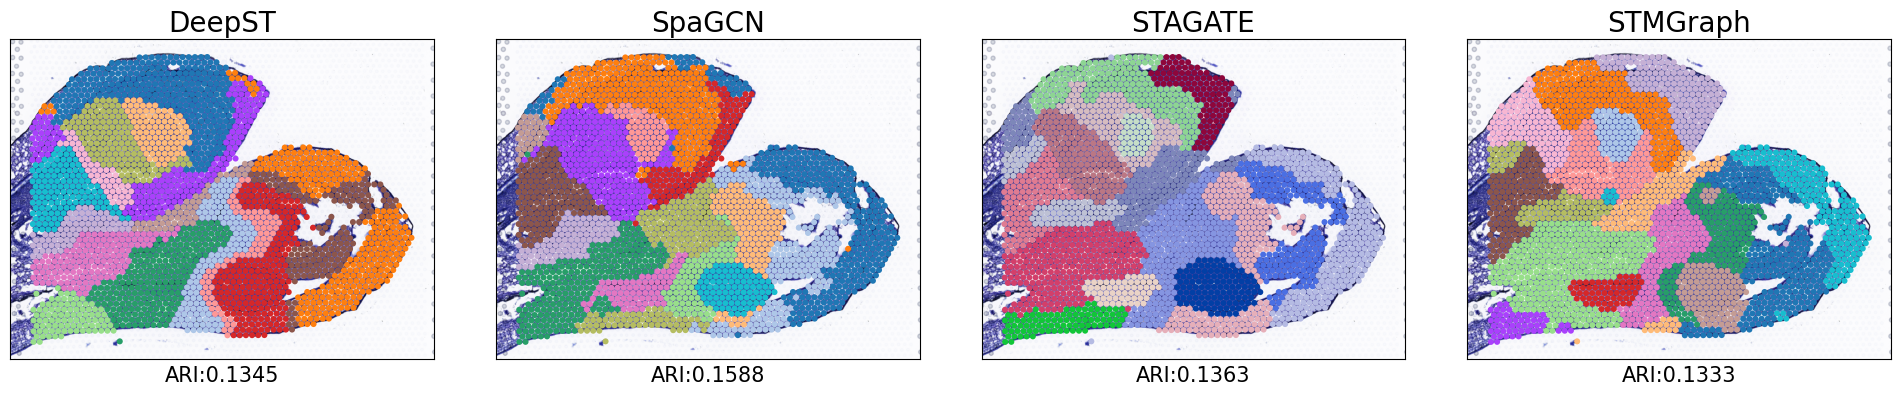

In [24]:
import matplotlib.pyplot as plt
fig,axs=plt.subplots(1,4,figsize=(20,4))


# sc.pl.embedding(adatas[0], basis='spatial', color='DeepST_refine_domain',ax=axs[0], title='DeepST', s=s_1, show=False)
# sc.pl.embedding(adatas[1], basis='spatial', color='refined_pred',        ax=axs[1], title="SpaGCN", s=s_1, show=False)
# sc.pl.embedding(adatas[2], basis='spatial', color='mclust',              ax=axs[2], title="STAGATE", s=s_1, show=False)
# sc.pl.embedding(adatas[3], basis='spatial', color='refine_mclust',       ax=axs[3], title="STMGraph", s=s_1, show=False)
# sc.pl.embedding(adatas[4], basis='spatial', color='AgaeSMO',       ax=axs[4], title="AgaeSMO", s=s_1, show=False)
# sc.pl.embedding(adatas[4], basis='spatial', color='groundtruth',ax=axs[5], title="GroundTruth", s=s_1, show=False)

sc.pl.spatial(DeepST___adata, basis='spatial', color='DeepST_refine_domain',ax=axs[0], title='DeepST',  s=s_1, show=False)
sc.pl.spatial(SpaGCN___adata, basis='spatial', color='refined_pred',        ax=axs[1], title="SpaGCN",  s=s_1, show=False)
sc.pl.spatial(STAGATE__adata, basis='spatial', color='mclust',              ax=axs[2], title="STAGATE", s=s_1, show=False)
sc.pl.spatial(STMGraph_adata, basis='spatial', color='refine_mclust',       ax=axs[3], title="STMGraph",s=s_1, show=False)
# sc.pl.spatial(AgaeSMO__adata, basis='spatial', color='AgaeSMO',               ax=axs[4], title="AgaeSMO", s=s_1, show=False)



plt.subplots_adjust(left=0.02, bottom=0.1, right=0.98, top=0.9, wspace=0.05, hspace=0.05)
# 3,7
# for i in axs:
for j in range(4):
    axs[j].set_xlabel("")
    axs[j].set_ylabel("")
    axs[j].set_title("", fontsize=20)
    
    # j.invert_yaxis()
    legend = axs[j].legend()
    legend.set_visible(False)  # 隐藏图例
    
# axs[4].set_xlabel("")
# axs[4].set_ylabel("")
# axs[4].set_title("", fontsize=20)

axs[0].set_title("DeepST",fontsize=20)
axs[1].set_title("SpaGCN",fontsize=20)
axs[2].set_title("STAGATE",fontsize=20)
axs[3].set_title("STMGraph",fontsize=20)
# axs[4].set_title("AgaeSMO",fontsize=20)

axs[0].set_xlabel(f"ARI:{DeepST_adata__ARI}", fontsize=15)
axs[1].set_xlabel(f"ARI:{SpaGCN_adata__ARI}", fontsize=15)
axs[2].set_xlabel(f"ARI:{STAGATE_adata_ARI}", fontsize=15)
axs[3].set_xlabel(f"ARI:{STMGraph_adataARI}", fontsize=15)
# axs[4].set_xlabel(f"ARI:{AgaeSMO_adata___ARI}", fontsize=15)
fig.savefig("plot/fig5_orchid.png",dpi=600)

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


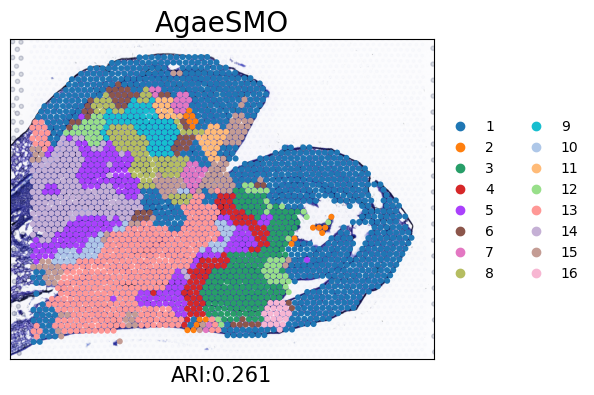

In [26]:
fig,axs=plt.subplots(1,figsize=(6,4))
sc.pl.spatial(AgaeSMO__adata, basis='spatial', color='AgaeSMO',               ax=axs, title="AgaeSMO", s=s_1, show=False)
plt.subplots_adjust(left=0.02, bottom=0.1, right=0.75, top=0.9, wspace=0.05, hspace=0.05)
axs.set_xlabel("")
axs.set_ylabel("")
axs.set_title("", fontsize=20)
axs.set_title("AgaeSMO",fontsize=20)
axs.set_xlabel(f"ARI:{AgaeSMO_adata___ARI}", fontsize=15)
fig.savefig("plot/fig5_orchid_AgaeSMO.png",dpi=600)

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


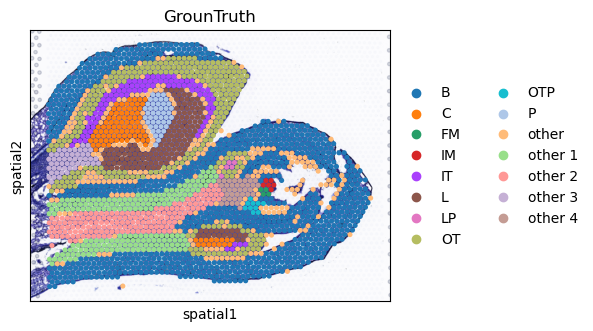

In [13]:
fig,axs=plt.subplots(1,figsize=(6,4))
sc.pl.spatial(AgaeSMO__adata, basis='spatial', color='GrounTruth', title='GrounTruth', ax=axs, s=s_1, show=False)
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.65, top=0.95, wspace=0.05, hspace=0.05)
plt.savefig("plot/fig5_orchid_groundtruth.png",dpi=600)